<a href="https://colab.research.google.com/github/kdkim2000/RAG2026/blob/main/%5B%EC%8B%A4%EC%8A%B5%5D_6_Advanced_RAG%2BRAG%EC%84%B1%EB%8A%A5%ED%8F%89%EA%B0%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [실습] RAG 성능 평가와 Advanced RAG

RAG의 기본 베이스 체인에서 시작하여, 다양한 기능을 추가해 보겠습니다.

In [1]:
%pip install ragas==0.4.0 sacrebleu dotenv jsonlines openai langchain langchain-openai langchain_qdrant 'langchain-community<0.4.2' tiktoken rank_bm25 pymupdf kiwipiepy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.1/397.1 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.7/25.7 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 30.9 MB/s eta 0:00:00
   ━━━

In [2]:
import os
from dotenv import load_dotenv
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from openai import OpenAI
from glob import glob
# 시스템/유틸리티
import os
import gc
import ast
import csv
import uuid
import datetime
import re

# API & 환경 설정
import openai
from openai import AsyncOpenAI
from dotenv import load_dotenv

# 데이터 처리 및 시각화
import pandas as pd
from tqdm import tqdm
from glob import glob

# 네트워크/웹 관련
import requests
import jsonlines
import bs4

from langchain_openai import OpenAIEmbeddings, ChatOpenAI

# LangChain 핵심 모듈
from langchain_community.document_loaders import PyMuPDFLoader, TextLoader
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableParallel
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Ragas 평가/지표 관련
from ragas import EvaluationDataset, evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
from ragas.metrics.collections import (
    ContextRecall,
    Faithfulness,
    FactualCorrectness,
    BleuScore,
    SemanticSimilarity
)

import logging

# OpenAI, httpx의 INFO 로그 차단
logging.getLogger("openai").setLevel(logging.WARNING)
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("httpcore").setLevel(logging.WARNING)

# RAGAS 사용 정보 수집 차단
os.environ["RAGAS_DO_NOT_TRACK"] = "true"
os.environ["DISABLE_TELEMETRY"] = "1"
os.environ["DO_NOT_TRACK"] = "1"

load_dotenv(override=True)

True

LLM을 준비합니다.

In [3]:
llm = ChatOpenAI(model='gpt-5.2', reasoning_effort='low')
print(llm.invoke("안녕?").text)

안녕하세요! 무엇을 도와드릴까요?


RAG_data.zip을 업로드하고, 압축을 해제합니다.

In [4]:
import zipfile
import os

# 압축 파일 이름 (현재 위치)
zip_filename = "RAG_data.zip"

# 압축 해제 경로 (data 폴더)
extract_path = "data"

try:
    # data 폴더 없으면 생성
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print(f"성공: {zip_filename}의 압축을 {extract_path}/ 폴더에 풀었습니다.")

except FileNotFoundError:
    print(f"오류: {zip_filename} 파일을 찾을 수 없습니다.")

except zipfile.BadZipFile:
    print("오류: 손상되었거나 유효하지 않은 zip 파일입니다.")

성공: RAG_data.zip의 압축을 data/ 폴더에 풀었습니다.


In [5]:
# 데이터 준비 / 전처리 / 벡터 데이터베이스 구성
def preprocess(docs):
    import re
    def clean_text(doc):
        text = doc.page_content
        text1 = re.sub(r'&[a-zA-Z0-9#]+;', '', text)
        text = text1
        text2 = re.sub(r'[\u200b\u00a0]', '', text)
        text = text2
        text3 = re.sub(r' {2,}', ' ', text2)
        text = text3.strip()
        doc.page_content = text
        return doc
    preprocessed_docs = []
    for doc in docs:
        doc = clean_text(doc)
        preprocessed_docs.append(doc)
    return preprocessed_docs

reports = glob('data/markdowns/*.md')
documents = []
for report in reports:
    loader = TextLoader(report)
    docs = loader.load()
    print('문서 로드 완료:', docs[0].metadata, docs[0].page_content[0:10], '...', len(docs[0].page_content))
    documents += docs
documents = preprocess(documents)

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
# 0~1000, 800~1800, 1600~2600, ...
chunks = text_splitter.split_documents(documents)
print(f'# 총 {len(chunks)} 개의 청크 생성')

문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md'} 인공지능 산업의 최 ... 41926
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_12월호_산업동향_1208_F.md'} ## 인공지능 산업 ... 39817
문서 로드 완료: {'source': 'data/markdowns/[2025.12 하나금융연구소](하나 Knowledge 25-38호) 금융투자업계에 스미는 AI.md'} ## 금융투자업계에 ... 14665
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'} 인공지능 산업의 최 ... 42825
문서 로드 완료: {'source': 'data/markdowns/[2025.12 구글]google_cloud_ai_agent_trends_2026_report.md'} ## AI agen ... 32781
문서 로드 완료: {'source': 'data/markdowns/[2025.12 삼일회계법인]2026대한민국산업지도.md'} ## 정부의전략산업 ... 112335
문서 로드 완료: {'source': 'data/markdowns/SPRi AI Brief_11월호_산업동향_1105_F.md'} 인공지능 산업의 최 ... 42931
# 총 415 개의 청크 생성


Qdrant Vector Store를 통해 DB를 구성합니다.

In [6]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams


openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-large', chunk_size=100)

uuidstr = str(uuid.uuid4())[0:6]
client = QdrantClient(path=f"outputs/vectordb/qdrant_{uuidstr}")

client.create_collection(
    collection_name=f"AI_Reports",
    vectors_config=VectorParams(size=3072, distance=Distance.EUCLID))

vector_store = QdrantVectorStore(
    client=client,
    collection_name=f"AI_Reports",
    embedding=openai_embeddings,
    distance=Distance.EUCLID)

vector_store.add_documents(chunks)

retriever = vector_store.as_retriever(search_kwargs={"k": 5})
print("벡터 DB와 Retriever 준비 완료!")

벡터 DB와 Retriever 준비 완료!


이전 실습과 유사하게, 프롬프트를 구성합니다.

In [7]:
from typing import Iterable, Sequence
from xml.sax.saxutils import escape
from langchain_core.documents import Document

def format_docs(
    docs: Iterable[Document],
    metadata_keys: Sequence[str] = ("source",),
) -> str:
    """
    List[Document] -> XML 직렬화 문자열.

    - 청크 경계: <document index="N"> 태그로 명시
    - 메타데이터: metadata_keys 에 지정한 키만 <meta>로 포함 (누락 키는 자동 생략)
    - 본문: XML 특수문자 escape (본문에 '<', '>' 가 있어도 경계 유지)
    """
    parts: list[str] = ["<documents>"]
    for i, doc in enumerate(docs, start=1):
        parts.append(f'  <document index="{i}">')
        for key in metadata_keys:
            value = doc.metadata.get(key)
            if value is None:
                continue
            parts.append(
                f'    <meta name="{escape(str(key))}">{escape(str(value))}</meta>'
            )
        parts.append(f"    <content>{escape(doc.page_content)}</content>")
        parts.append("  </document>")
    parts.append("</documents>")
    return "\n".join(parts)

prompt = ChatPromptTemplate([
    ("system", '''당신은 QA(Question-Answering)을 수행하는 Assistant입니다.
다양한 출처의 보고서 일부 내용이 Context로 주어집니다.
Context의 내용을 바탕으로 Question에 대한 답변을 제공하세요.

만약 Context가 질문과 무관하거나 관련 정보가 없다면,
"정보가 부족하여 답변할 수 없습니다."를 출력하세요.'''),
    ("human",'''Context: {context}
---
Question: {question}''')])


rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser())

print("RAG 체인 준비 완료!")

RAG 체인 준비 완료!


# RAG 성능 평가하기   

구성한 RAG의 성능은 어떻게 평가할까요?   

RAGAS (https://docs.ragas.io/en/stable/)는 다양한 메트릭을 통한 RAG의 성능 평가를 지원합니다.

RAG의 평가를 위해서는 정답이 있는 Q/A 데이터가 필요합니다.   
실습 시트에서 eval.jsonl을 다운로드하여 불러옵니다.

In [8]:
import pandas as pd
df = pd.read_csv('data/evaluation/rag_evaluation_data.csv')

eval_dataset = df.to_dict('list')
questions, ground_truths, qtypes = eval_dataset['question'], eval_dataset['answer'], eval_dataset['difficulty']
for i in range(len(questions)):
    print(f'#{i} ', end='')
    print(f'({qtypes[i]})')
    print(f'Question: {questions[i]}\n')
    print(f'Ground Truth: {ground_truths[i]}\n')
    print('-----------')

#0 (Easy)
Question: 1X가 출시한 가정용 휴머노이드 로봇 네오의 예약 판매 가격과 배송 일정은?

Ground Truth: 네오'의 예약 판매 가격은 2만 달러이며, 2026년부터 미국 내 소비자를 대상으로 우선적으로 제품을 배송한 뒤, 2027년부터는 판매 대상 지역을 해외 시장으로 단계적으로 확대할 계획이다. 또한, 추후에는 월 499달러를 지불하는 구독형 서비스 모델도 별도로 제공할 예정이다.

-----------
#1 (Easy)
Question: 구글 리포트에서 말하는 AI 에이전트란 무엇인가요?

Ground Truth: 구글 리포트에서 정의하는 AI 에이전트란,
단순히 질문에 답을 생성하는 AI가 아니라 목표를 이해하고, 그 목표를 달성하기 위한 계획을 세운 뒤, 실제로 여러 시스템과 도구를 넘나들며 행동까지 수행하는 AI 시스템을 의미합니다.

리포트에 따르면 AI 에이전트는 고급 AI 모델의 지능과 외부 도구 및 데이터에 대한 접근 능력을 결합한 시스템으로, 사용자의 통제와 감독 하에 사용자를 대신해 행동할 수 있습니다. 이 때문에 AI 에이전트는 기존의 “보조적인 기능(add-on)”이 아니라, 업무 흐름 자체가 AI를 중심으로 재구성되는 AI-first 프로세스의 핵심 구성 요소로 설명됩니다.

또한 이 리포트는 AI 에이전트를 인간을 대체하는 존재로 보지 않습니다. 오히려 인간은 여전히 목표를 설정하고, 전략을 제시하며, 결과를 검증하는 최종 의사결정자이자 오케스트레이터로 남고, 에이전트는 그 과정을 증폭시키는 역할을 맡는다고 명확히 설명합니다. 즉, AI 에이전트는 스스로 판단해 무작위로 행동하는 존재가 아니라, 인간의 의도와 감독 아래에서 계획·실행·조정을 반복하는 행동 가능한 AI 시스템입니다

-----------
#2 (Easy)
Question: 보고서에서 다뤄진 미국-유럽의 방위 정책 강화 과정에 대해 설명해주세요.

Ground Truth: 보고서는 러?우 전쟁 이후 지정학적 갈등이 장기화되면서 방위비 지출

구성된 RAG 체인을 이용해, RAGAS의 Evaluate에 필요한 데이터를 구성합니다.

In [9]:
dataset = []

result = rag_chain.batch(questions)
relevant_docs_list = retriever.batch(questions)

for i, ans in enumerate(result):
    print(f"Question: {questions[i]}")

    relevant_docs = [doc.page_content for doc in relevant_docs_list[i]]
    print(f"Answer: {ans}")
    print('---')

    dataset.append(
        {
            "user_input":questions[i],
            "retrieved_contexts":relevant_docs,
            "response":ans,
            "reference":ground_truths[i]
        }
    )

Question: 1X가 출시한 가정용 휴머노이드 로봇 네오의 예약 판매 가격과 배송 일정은?
Answer: 1X의 가정용 휴머노이드 로봇 **‘네오(Neo)’ 예약 판매 가격은 2만 달러**이며, **2026년에 미국 소비자에게 우선 배송**을 시작하고 **2027년부터 해외 시장으로 배송/판매를 확대**할 계획입니다.
---
Question: 구글 리포트에서 말하는 AI 에이전트란 무엇인가요?
Answer: 구글 클라우드 리포트에서 말하는 **AI 에이전트(AI agent)**는 **고도화된 AI 모델의 지능**에 더해 **각종 도구(tool)에 접근**할 수 있어, **사용자를 대신해(통제 하에) 실제 행동을 수행하는 시스템**을 의미합니다. (예: 필요한 툴을 호출하거나 작업을 실행)

리포트에서는 이를 단순히 AI를 “추가 기능(add-on)”으로 붙이는 수준이 아니라, **업무 프로세스 자체를 ‘AI-first’로 바꾸는 근본적인 워크플로 변화**라고 설명합니다.
---
Question: 보고서에서 다뤄진 미국-유럽의 방위 정책 강화 과정에 대해 설명해주세요.
Answer: 보고서에서는 미국과 유럽이 지정학적 불안(러–우 전쟁 등) 지속과 전쟁 양상의 변화(사이버·전자전, AI 활용 확대)에 대응해 **방위정책을 “예산 확대–제도/조달 개편–첨단전력 투자–동맹 차원의 지출 목표 상향”**의 흐름으로 강화해 왔다고 설명합니다.

## 1) 촉발 요인: 지정학 리스크 상수화 + 전쟁 패러다임 변화
- 러–우 전쟁을 계기로 글로벌 방위비 지출 증가가 본격화됐고, 이후 갈등이 지속되며 방위력 강화가 구조적 흐름으로 자리 잡았다고 봅니다.
- 전쟁 영역이 확대되고 무기체계가 고도화되면서 미래전이 **사이버전·전자전·AI 활용** 중심으로 변모해 **국방 R&D 증액과 재래식 무기 현대화**가 필수라고 제시합니다.

## 2) 미국: ‘국방수권법(NDAA)’ 중심으로 예산·조달·첨단투자 강화
- 트럼프 2기 정책 변화로 **미국 우선주의**와 “세계 경찰 역할

## RAGAS: RAG 성능 평가 프레임워크
RAGAS는 LLM을 이용해 정답과 답변을 개별 Claim(주장)으로 분할합니다.

이후, `LLMContextRecall`, `Faithfulness`, `FactualCorrectness` 등의 다양한 메트릭을 통해 RAG 파이프라인의 성능을 평가합니다.   
LLM 기반의 방법이므로 평가 LLM의 선정이 중요하며, 절대 수치보다는 상대적 비교가 효과적입니다.


- Context Recall: 정답의 Claim이 검색된 비율
- Faithfulness : 답변의 Claim이 검색 결과에 근거한 정도
- Factual Correctness : 정답과 답변의 Claim 일치도
- Bleu Score : 정답과 답변의 키워드 일치도
- Semantic Sim : 정답과 답변 임베딩의 유사도   


In [10]:
from ragas import EvaluationDataset
evaluation_dataset = EvaluationDataset.from_list(dataset)
evaluation_dataset

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response', 'reference'], len=20)

In [11]:
# Ragas 평가/지표 관련
from ragas import EvaluationDataset, aevaluate, RunConfig
from ragas.llms import llm_factory
from ragas.embeddings import OpenAIEmbeddings as RagasOpenAIEmbeddings
from ragas.metrics import (
    ContextRecall,
    Faithfulness,
    FactualCorrectness,
    BleuScore,
    SemanticSimilarity
)
from langchain_openai import ChatOpenAI
from openai import AsyncOpenAI


# OpenAI 클라이언트 생성
client = AsyncOpenAI()

# https://docs.ragas.io/en/stable/concepts/metrics/available_metrics/

# 평가자 LLM
evaluator_llm = llm_factory('gpt-4.1-mini', client=client, temperature=0.1, max_tokens=8192)

# 평가자 Embedding
evaluator_embeddings = RagasOpenAIEmbeddings(model="text-embedding-3-large", client=client)
semantic_scorer = SemanticSimilarity(embeddings = evaluator_embeddings)

# 20개 질문을 병렬로 평가
run_config = RunConfig(max_workers=32)

print("평가자 준비 완료!")

평가자 준비 완료!


In [12]:
result = await aevaluate(
    dataset=evaluation_dataset,
    metrics=[
        BleuScore(),
        ContextRecall(),
        semantic_scorer,
        Faithfulness(),
        FactualCorrectness(),
    ],
    llm=evaluator_llm,
    embeddings=evaluator_embeddings,
    run_config=run_config,
)

result

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2633, 'context_recall': 0.7392, 'semantic_similarity': 0.7966, 'faithfulness': 0.7512, 'factual_correctness(mode=f1)': 0.6920}

In [13]:
result.scores[0:3]

[{'bleu_score': 0.06698651592727944,
  'context_recall': 1.0,
  'semantic_similarity': 0.7157434706155416,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.86)},
 {'bleu_score': 0.024099933988091075,
  'context_recall': 0.6666666666666666,
  'semantic_similarity': 0.7903092021832565,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.67)},
 {'bleu_score': 0.03095781486612299,
  'context_recall': 1.0,
  'semantic_similarity': 0.8141538915471985,
  'faithfulness': 1.0,
  'factual_correctness(mode=f1)': np.float64(0.62)}]

In [14]:
detailed_result = result.to_pandas()
os.makedirs('outputs/eval', exist_ok=True)
detailed_result.to_csv('outputs/eval/ragas_result.csv', encoding='utf-8', errors='ignore', index=False)

기본적인 구조의 RAG 성능을 확인해 보았습니다.

평가를 위해, 이후에는 평가 함수를 별도로 구성합니다.

In [15]:
def rag_answer_batch(questions, rag_chain, retriever):
    """질문 리스트를 받아 (답변 리스트, 근거 컨텍스트 리스트)를 반환합니다."""
    answers = rag_chain.batch(questions)
    contexts = [[doc.page_content for doc in docs] for docs in retriever.batch(questions)]
    return answers, contexts


async def evaluate_rag(name, answer_fn):
    """검색 방식을 바꿔 가며 같은 지표로 비교합니다.

    name: 결과 파일 이름에 사용할 방식 이름
    answer_fn: 질문 리스트를 받아 (답변, 근거 컨텍스트)를 돌려주는 함수
    """
    answers, contexts = answer_fn(questions)

    new_dataset = [
        {
            "user_input": question,
            "retrieved_contexts": context,
            "response": answer,
            "reference": ground_truth,
        }
        for question, context, answer, ground_truth
        in zip(questions, contexts, answers, ground_truths)
    ]

    evaluation_dataset = EvaluationDataset.from_list(new_dataset)

    result = await aevaluate(
        dataset=evaluation_dataset,
        metrics=[
            BleuScore(),
            ContextRecall(),
            semantic_scorer,
            Faithfulness(),
            FactualCorrectness()
        ],
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
        run_config=run_config
    )

    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    os.makedirs('outputs/eval', exist_ok=True)
    csv_filename = f'outputs/eval/ragas_result_{name}_{timestamp}.csv'
    result.to_pandas().to_csv(csv_filename, encoding='utf-8', errors='ignore', index=False)

    return result

# Multi-Query Retriever   

검색 쿼리를 바로 retrieve하는 대신, 검색 쿼리를 미리 생성합니다.   


In [16]:
# Multi Query를 확인하기 위한 로깅
import logging

logging.basicConfig()
logging.getLogger('langchain_classic.retrievers.multi_query').setLevel(logging.INFO)

In [17]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_classic.retrievers.multi_query import MultiQueryRetriever


rewrite_prompt = ChatPromptTemplate([
    ('system','''Retrieval Augmented Generation을 위해,
주어진 질문에 정확한 답변을 수행하기 위한 검색 쿼리를 작성하세요.
원본 질문을 포함해, 사용자의 질문을 해결하기 위해 검색해야 하는 4개의 쿼리를 한 줄에 하나씩 출력하세요.
'구글'에 관한 질문의 경우에는 영문 질문을 포함하세요.
각 질문들은 완성된 질문 형태로 생성하고, 한 줄에 하나씩 새로운 줄로 구분하여 제공하세요.'''),
    ('human','''
---
원본 질문: {question}''')])

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=vector_store.as_retriever(),
    llm=llm,
    prompt = rewrite_prompt,
)

In [19]:
enhanced_context = multi_query_retriever.invoke("트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?")

len(enhanced_context)

INFO:langchain_classic.retrievers.multi_query:Generated queries: ['트럼프 미국 대통령이 서명한 ‘제네시스 미션(Genesis Mission)’ 행정명령의 핵심 목표는 무엇인가요?  ', '‘제네시스 미션’(Genesis Mission) 행정명령 전문(text)과 목적(purpose) 조항은 무엇인가요?  ', 'Trump “Genesis Mission” executive order main goal what is it?  ', '‘Genesis Mission’ executive order summary 핵심 목표 추진 내용은 무엇인가요?']


7

In [20]:
multiquery_rag_chain = (
    {"context": multi_query_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [21]:
await evaluate_rag('multiquery', lambda qs: rag_answer_batch(qs, multiquery_rag_chain, multi_query_retriever))

INFO:langchain_classic.retrievers.multi_query:Generated queries: ['트럼프 미국 대통령이 서명한 ‘제네시스 미션(Genesis Mission)’ 행정명령의 핵심 목표는 무엇인가요?  ', 'What is the main goal of the “Genesis Mission” executive order signed by U.S. President Donald Trump?  ', '트럼프 ‘Genesis Mission’ 행정명령 전문(full text)과 목적(목표) 요약은 무엇인가요?  ', '‘Genesis Mission’ 행정명령이 지시한 구체적 정책 과제(우주 탐사/국방/에너지/과학 연구 등)는 무엇인가요?']
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['삼일회계법인 산업지도에서 “ABCDE+2S”의 정의(의미)는 무엇인가요?  ', '삼일회계법인(PwC Korea) 산업지도(Industry Map)에서 기업 분류/등급 체계 “A~E”는 각각 무엇을 뜻하나요?  ', '삼일회계법인 산업지도에서 “2S”는 무엇의 약자이며 어떤 항목(지표/평가요소)을 의미하나요?  ', 'What does “ABCDE+2S” mean in PwC Korea (Samil PwC) Industry Map/Industry Guide?']
INFO:langchain_classic.retrievers.multi_query:Generated queries: ['1X가 출시한 가정용 휴머노이드 로봇 ‘네오(NEO)’의 예약 판매(프리오더) 가격은 얼마인가?  ', '1X의 가정용 휴머노이드 로봇 NEO의 예약 판매 시작일과 배송(출고) 예정 일정은 어떻게 공지되었는가?  ', '1X NEO 예약 판매 가격 및 배송 일정이 1X 공식 발표(보도자료/공식 블로그/공식 SNS)에서 어떻게 명시되어 있는가?  ', 'What is the pre-order price an

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2476, 'context_recall': 0.8400, 'semantic_similarity': 0.8376, 'faithfulness': 0.8138, 'factual_correctness(mode=f1)': 0.7385}


### Ensemble Retriever

Lexical 검색인 BM25와 Semantic 검색인 임베딩 방법을 조합할 수도 있습니다.    
기본 BM25 리트리버는 한국어 처리가 어려우므로, Kiwi 형태소 분석기를 사용합니다.

In [22]:
from kiwipiepy import Kiwi

kiwi = Kiwi()
# Kiwi 형태소 분석기: 고유명사를 추가할 수도 있음
def kiwi_tokenize(text):
    return [token.form for token in kiwi.tokenize(text)]


In [23]:
from langchain_classic.retrievers import BM25Retriever, EnsembleRetriever

# BM25: 단어의 중요도에 따라 가중치를 부여하는 인덱싱 방법
bm25_retriever = BM25Retriever.from_documents(chunks, preprocess_func = kiwi_tokenize)
bm25_retriever.k = 5

retriever = vector_store.as_retriever(search_kwargs={"k": 5})

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever], weights=[0.5, 0.5]
    # 합집합
)

In [24]:
ensemble_rag_chain = (
    {"context": ensemble_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [25]:
await evaluate_rag('ensemble', lambda qs: rag_answer_batch(qs, ensemble_rag_chain, ensemble_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2499, 'context_recall': 0.8108, 'semantic_similarity': 0.8413, 'faithfulness': 0.7615, 'factual_correctness(mode=f1)': 0.7325}

### Reranker

High K로 검색한 후보 청크를 다시 정렬해, 관련도가 높은 청크만 남기는 단계입니다.

리랭커는 쿼리와 청크의 관련도를 직접 출력하는 모델을 쓰는 방법과, LLM에게 점수를 매기게 하는 방법이 있습니다.
여기서는 LLM 리랭커를 사용합니다.

In [26]:
from langchain_core.retrievers import BaseRetriever
from langchain_core.runnables import Runnable
from typing import List

rerank_prompt = ChatPromptTemplate([
    ('system', '''질문에 답하는 데 문서가 얼마나 도움이 되는지 0에서 10 사이의 정수로 평가하세요.
숫자만 출력하세요.'''),
    ('human', '''질문: {question}
---
문서: {document}''')
])

rerank_chain = rerank_prompt | llm | StrOutputParser()


def parse_score(text):
    matched = re.search(r'\d+', text)
    return int(matched.group()) if matched else 0


class LLMRerankRetriever(BaseRetriever):
    """후보 문서를 LLM이 매긴 점수 순으로 정렬해 상위 top_k개를 반환합니다."""
    base_retriever: BaseRetriever
    reranker: Runnable
    top_k: int = 5

    def _get_relevant_documents(self, query: str, *, run_manager=None) -> List[Document]:
        candidates = self.base_retriever.invoke(query)
        scores = self.reranker.batch(
            [{'question': query, 'document': doc.page_content} for doc in candidates]
        )
        ranked = sorted(zip(candidates, scores), key=lambda pair: parse_score(pair[1]), reverse=True)
        return [doc for doc, score in ranked[:self.top_k]]

In [27]:
# 리랭킹할 후보를 넉넉히 검색합니다
bm25_candidates = BM25Retriever.from_documents(chunks, preprocess_func=kiwi_tokenize)
bm25_candidates.k = 8

candidate_retriever = EnsembleRetriever(
    retrievers=[bm25_candidates, vector_store.as_retriever(search_kwargs={"k": 8})],
    weights=[0.5, 0.5]
)

rerank_retriever = LLMRerankRetriever(
    base_retriever=candidate_retriever,
    reranker=rerank_chain,
    top_k=5,
)

reranked = rerank_retriever.invoke("트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?")
print(f'후보 {len(candidate_retriever.invoke("제네시스 미션"))}개 중 {len(reranked)}개 선택')

후보 13개 중 5개 선택


In [28]:
rerank_rag_chain = (
    {"context": rerank_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

await evaluate_rag('rerank', lambda qs: rag_answer_batch(qs, rerank_rag_chain, rerank_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2615, 'context_recall': 0.7940, 'semantic_similarity': 0.8079, 'faithfulness': 0.7275, 'factual_correctness(mode=f1)': 0.7105}

# Contextual Retrieval    

Anthropic이 2024년 9월 처음으로 제안한 Contextual Retrieval은 전체 Context를 활용하여     
청크별 헤더를 추가하는 방법입니다.    

In [29]:
chunks = text_splitter.split_documents(documents)
chunks[40]

Document(metadata={'source': 'data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md'}, page_content="출처 | NVIDIA, At NeurIPS, NVIDIA Advances Open Model Development for Digital and Physical AI, 2025.12.01.\n\n## 미국 프린스턴⼤ 등 공동 연구진, 다중 에이전트 협업 프레임워크 개발\n\n## KEY Contents\n\n- n 프린스턴⼤ 등의 공동 연구진이 여러 LLM 에이전트가 텍스트를 주고받는 대신, 내부 사고와 작업 기억을 직접 공유하는 다중 에이전트 협업 프레임워크 'LatentMAS'를 개발\n- n 연구진의 실험 결과, LatentMAS는 기존 텍스트 기반 다중 에이전트 시스템 대비 작업 정확도나 처리 속도가 향상되었으며 토큰 효율성도 향상된 것으로 확인\n\n## £ LatentMAS, 모델 내부의 사고와 작업 기억을 직접 전달해 에이전트 간 효율적 협업 지원\n\n- n 미국 프린스턴⼤, 스탠퍼드⼤ 등의 공동 연구진이 다중 에이전트 시스템의 협업 성능과 처리 속도, 연산 효율성을 모두 개선하는 'LatentMAS' 프레임워크를 개발\n- 에이전트 간 소통을 위해 텍스트를 매개체로 사용하는 기존 다중 에이전트 시스템은 모델 내부의 고차원 정보를 텍스트 토큰으로 변환하는 과정에서 일부 정보가 손실되고 상당한 연산 비용과 지연이 발생\n- 연구진은 이러한 한계를 극복하기 위해 에이전트 간 협업이 텍스트를 통해서가 아니라 '잠재 공간(Latent Space)*'에서 이루어짐으로써 모델 내부의 사고 과정과 작업 기억을 직접 전송하는 프레임워크를 고안 * 입력 데이터가 모델 내부에서 의미·패턴 단위의 숫자 벡터로 표현되어 배치되는 고차원 공간\n- 이 시스템은 별도의 추가 학습 없이 기존 LLM의 내부 구조를 활용해 구현되며, 각 에이전트는 텍스트 토큰을 생성하는 대신 LLM 내부의 사고를 손실 없이 다

In [30]:
context_prompt = ChatPromptTemplate([
    ('system', '''RAG 검색용 청크에 빠져 있는 문맥 정보를 한국어 1-2문장으로 보강하세요.
청크에 이미 있는 내용은 반복하지 마세요.

## 우선 포함할 정보 (문서에서 확인 가능한 것만)
1. 문서의 종류·제목·출처: 회사/기관명, 보고서·논문·매뉴얼명, 분기·연도
2. 청크가 속한 상위 섹션 또는 소주제
3. 청크 내 대명사·생략 주어가 가리키는 고유명사 (회사, 인물, 제품, 사건, 코드명 등)
4. 비교·연속·인과 관계가 있다면 비교 대상 또는 직전 맥락의 핵심 수치/사실

## 작성하지 않을 것
- 청크 본문의 요약·재진술
- "이 부분은 ~을 설명한다" 같은 메타 서술
- 추상적 주제 해석이나 평가
- 문서에서 확인되지 않는 추측

## 출력 형식
- 한국어 1-2문장, 약 50-100 토큰
- 머리말·꼬리말·번호·따옴표 없이 본문만
- 문서에서 확인 가능한 정보가 부족하면 무리하게 채우지 말고 짧게 마무리'''),
    ('user', '''<document>
{document}
</document>

<chunk>
{chunk}
</chunk>

Context:''')
])

#Long Context 처리
long_llm = ChatOpenAI(model='gpt-5.2', max_tokens=8192)


context_chain = context_prompt | long_llm | StrOutputParser()


Context가 잘 생성됐는지 확인해 봅니다.

In [32]:
chunk = chunks[35]
source = TextLoader(chunk.metadata['source']).load()[0].page_content
context = context_chain.invoke({'document':source, 'chunk':chunk.page_content})
print(context)
print('========')
print(chunk.page_content)

SPRi의 ‘인공지능 산업의 최신 동향(SPRi AI Brief) 2026년 1월호’ 중 ‘기업·산업 > 리눅스 재단, 주요 기업 연합 에이전틱 AI 재단(AAIF) 출범’ 섹션에 해당한다. 여기서 ‘AAIF’는 리눅스 재단 산하 Agentic AI Foundation을, ‘구스(Goose)’는 블록(Block)의 로컬 실행 오픈소스 에이전트 프레임워크를 가리킨다.
- 블록은 에이전틱 AI의 안전하고 일관성 있는 발전에 필요한 실질적 인프라를 제공하는 구스의 운영을 AAIF에 맡김으로써 개방형 생태계 기반 에이전틱 AI의 발전을 보장할 수 있을 것으로 기대
- n 오픈AI는 코딩 에이전트가 다양한 저장소와 툴체인 환경에서 일관된 방식으로 작동하도록 돕는 간단한 범용 표준인 'AGENTS.md'(2025년 8월 공개)의 운영을 AAIF에 이관
- AGENTS.md는 이미 코덱스(Codex), 커서(Cursor), 데빈(Devin), 깃허브 코파일럿(Github Copilot), 제미나이 CLI(Gemini CLI)를 포함한 6만 개 이상의 오픈소스 프로젝트와 에이전트 프레임워크에 채택
- 오픈AI는 AI 에이전트의 발전을 위해서는 신뢰성 있는 인프라와 접근성이 뛰어난 도구 기반의 에이전트 구축이 필수적이라며, AGENTS.md를 통해 상호운용성과 안전성을 갖춘 에이전트 개발 관행이 확립될 것으로 기대
- 출처 | Agentic AI Foundation, Linux Foundation Announces the Formation of the Agentic AI Foundation (AAIF), Anchored by New Project Contributions Including Model Context Protocol (MCP), goose and AGENTS.md, 2025.12.09.


이제 Context 추가 작업을 수행합니다.

In [33]:
# from langchain_core.documents import Document
# import jsonlines
# from tqdm import tqdm
# def save_docs_to_jsonl(documents, file_path):
#     with jsonlines.open(file_path, mode="w") as writer:
#         for doc in documents:
#             writer.write(doc.model_dump())
# for i, chunk in enumerate(tqdm(chunks)):
#     source = TextLoader(chunk.metadata['source']).load()[0].page_content
#     context = context_chain.invoke({'document':source, 'chunk':chunk.page_content})
#     print('\n'+context)
#     print('---')
#     chunks[i].page_content = context + '\n\n' + chunks[i].page_content
# save_docs_to_jsonl(chunks, './chunks_export.jsonl')


from langchain_core.documents import Document
import jsonlines
def load_docs_from_jsonl(file_path):
    documents = []
    with jsonlines.open(file_path, mode="r") as reader:
        for doc in reader:
            documents.append(Document(**doc))
    return documents

chunks = load_docs_from_jsonl("data/evaluation/chunks_export.jsonl")
chunks[0:3]

[Document(metadata={'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'}, page_content="이 문서는 SPRi에서 2025년 10월에 발간한 인공지능 산업 최신 동향 보고서 'SPRi AI Brief'로, 정책·법제, 기업·산업, 기술·연구, 인력·교육 등 AI 분야 전반의 최신 소식을 다루고 있다.\n\n인공지능 산업의 최신 동향\n\nSPRi AI Brief\n\n## CONTENTS"),
 Document(metadata={'source': 'data/markdowns/SPRi AI Brief_10월호_산업동향_1002_F.md'}, page_content="이 문서는 2025년 10월 발행된 SPRi AI Brief의 목차 부분으로, 인공지능 산업의 최신 동향을 다루고 있다. 각 분야별로 정책, 기업, 기술 연구 등에 관한 핵심 소식들이 정리되어 있으며, 예를 들어 중국 국무원의 'AI 플러스' 정책 로드맵 발표, 대만의 AI 기본법 통과, 영국 AI 산업 현황 보고서 발간, 미국 캘리포니아주의 AI 챗봇 규제 등 주요 국가들의 AI 정책과 규제 동향을 포함한다.\n\n| 정책 ･ 법제 | ∙ 중국 국무원, 'AI 플러스' 심화 추진을 위한 정책 로드맵 발표 | 2 |\n|---------------|------------------------------------------------------------------------|-----|\n| | ∙ 대만 행정원, AI 기본법 통과 후 입법원에 제출 | 3 |\n| | ∙ 영국 과학혁신기술부, 2024년 영국 AI산업 현황 분석 보고서 발간 | 4 |\n| | ∙ 미국캘리포니아주의회,미국최초로미성년자보호를위한AI챗봇규제통과 | 5 |\n| | ∙ 중국 국가인터넷정보판공실, AI 안전 거버넌스 프레임워크 2.0 버전 발표 | 6 |\n| 기업 ･ 산업 | ∙ 구글, 이미지 편집 모델 '제미나이 2.5 플래시 이미지' 공개

Chunk의 결과가 추가되었으니, 벡터 데이터베이스를 다시 구성합니다.

In [34]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

openai_embeddings = OpenAIEmbeddings(model='text-embedding-3-large', chunk_size=100)

uuidstr = str(uuid.uuid4())[0:6]
client = QdrantClient(path=f"outputs/vectordb/qdrant_{uuidstr}")
client.create_collection(
    collection_name=f"AI_Reports_Contextual",
    vectors_config=VectorParams(size=3072, distance=Distance.EUCLID))
vector_store = QdrantVectorStore(
    client=client,
    collection_name=f"AI_Reports_Contextual",
    embedding=openai_embeddings,
    distance=Distance.EUCLID)

vector_store.add_documents(chunks)
retriever = vector_store.as_retriever(search_kwargs={"k": 5})

Contextual Header를 이용하기 위해, BM25와 Semantic Search를 결합합니다.

In [35]:
bm25_retriever = BM25Retriever.from_documents(chunks, preprocess_func = kiwi_tokenize)
bm25_retriever.k = 5

retriever = vector_store.as_retriever(search_kwargs={"k": 5})

ensemble_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, retriever], weights=[0.5, 0.5]
)

In [36]:
contextual_rag_chain = (
    {"context": ensemble_retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

await evaluate_rag('contextual', lambda qs: rag_answer_batch(qs, contextual_rag_chain, ensemble_retriever))

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2580, 'context_recall': 0.8548, 'semantic_similarity': 0.8476, 'faithfulness': 0.7523, 'factual_correctness(mode=f1)': 0.7710}

1. 기본 RAG 결과:

bleu_score: 0.2633
context_recall: 0.7392
semantic_similarity: 0.7966
faithfulness: 0.7512
factual_correctness(mode=f1): 0.6920
2. Multi-Query RAG 결과:

bleu_score: 0.2476
context_recall: 0.8400
semantic_similarity: 0.8376
faithfulness: 0.8138
factual_correctness(mode=f1): 0.7385
3. 하이브리드(Ensemble) RAG 결과:

bleu_score: 0.2499
context_recall: 0.8108
semantic_similarity: 0.8413
faithfulness: 0.7615
factual_correctness(mode=f1): 0.7325
4. Rerank RAG 결과:

bleu_score: 0.2615
context_recall: 0.7940
semantic_similarity: 0.8079
faithfulness: 0.7275
factual_correctness(mode=f1): 0.7105
5. Contextual RAG 결과:

bleu_score: 0.2580
context_recall: 0.8548
semantic_similarity: 0.8476
faithfulness: 0.7523
factual_correctness(mode=f1): 0.7710
결과 비교 및 해석:

Bleu Score (블루 점수):

기본 RAG (0.2633)가 가장 높았고, Rerank (0.2615)와 Contextual (0.2580)이 그 다음으로 높게 나타났습니다. Multi-Query (0.2476)와 하이브리드 (0.2499)는 비교적 낮았습니다.
해석: 블루 점수는 어휘적 중첩을 측정합니다. Multi-Query와 하이브리드 방식은 쿼리를 확장하거나 검색 방식을 조합하여 더 넓은 범위의 컨텍스트를 찾으므로, 원본 질문과 다른 표현으로 답변을 구성할 가능성이 있어 어휘적 일치도가 떨어질 수 있습니다. Rerank와 Contextual은 검색된 컨텍스트를 정제하거나 보강하는 방식이므로, 답변의 어휘적 다양성에는 큰 영향을 미치지 않아 기본 RAG와 유사한 점수를 보인 것으로 판단됩니다.
Context Recall (컨텍스트 회수율):

Contextual RAG (0.8548)가 가장 높은 회수율을 기록했습니다. Multi-Query RAG (0.8400)가 그 뒤를 이으며 높은 성능을 보였습니다. 하이브리드 RAG (0.8108)와 Rerank RAG (0.7940)도 기본 RAG (0.7392)보다 우수했습니다.
해석: Contextual RAG는 청크에 주변 문맥 정보를 직접 추가함으로써, 검색 시 해당 청크의 관련성이 더욱 명확하게 드러나 회수율이 높아진 것으로 보입니다. Multi-Query는 여러 쿼리를 생성하여 넓은 범위의 문서를 탐색했기 때문에 높은 회수율을 보였습니다. 하이브리드도 BM25와 임베딩 검색을 조합하여 기본 RAG보다 관련 정보를 더 잘 찾아냈습니다. Rerank는 LLM 기반으로 관련성이 높은 청크를 선별했음에도 Contextual이나 Multi-Query만큼의 회수율 향상에는 미치지 못했습니다. 이는 컨텍스트 보강이나 쿼리 확장이 검색 단계에서 더 효과적일 수 있음을 시사합니다.
Semantic Similarity (의미론적 유사성):

Contextual RAG (0.8476)가 가장 높았고, 하이브리드 RAG (0.8413)와 Multi-Query RAG (0.8376)가 매우 근소한 차이로 뒤를 이었습니다. Rerank RAG (0.8079)와 기본 RAG (0.7966)는 상대적으로 낮았습니다.
해석: Contextual, 하이브리드, Multi-Query 세 방식 모두 기본 RAG보다 생성된 답변이 정답과 '의미적으로' 더 유사하다는 것을 강력히 보여줍니다. 특히 Contextual RAG는 보강된 문맥 정보가 LLM이 질문의 의도에 더 정확하게 부합하는 답변을 생성하는 데 도움을 주어 최고의 의미론적 유사성을 달성한 것으로 보입니다.
Faithfulness (충실도):

Multi-Query RAG (0.8138)가 가장 높았고, 하이브리드 RAG (0.7615), Contextual RAG (0.7523) 순이었습니다. 기본 RAG (0.7512)는 Contextual RAG와 거의 비슷했으며, Rerank RAG (0.7275)는 가장 낮은 충실도를 보였습니다.
해석: Multi-Query RAG는 가장 높은 충실도를 기록하며, 다양한 쿼리를 통해 확보한 풍부하고 관련성 높은 컨텍스트가 LLM의 환각(Hallucination)을 줄이는 데 가장 효과적이었음을 입증합니다. Contextual RAG는 컨텍스트 회수율이 높았음에도 불구하고 충실도에서는 Multi-Query보다 약간 낮은데, 이는 보강된 컨텍스트가 때로는 LLM에게 더 많은 해석의 여지를 주었거나, LLM이 보강된 정보와 원본 청크 간의 관계를 완전히 일치시키지 못했을 가능성을 시사합니다. Rerank RAG의 낮은 충실도는 LLM 기반 Reranker가 선별한 컨텍스트가 LLM으로 하여금 답변을 검색된 정보에만 국한시키도록 하는 데는 덜 효과적이었을 수 있음을 나타냅니다.
Factual Correctness (사실 정확성, F1):

Contextual RAG (0.7710)가 가장 높았고, Multi-Query RAG (0.7385)와 하이브리드 RAG (0.7325)가 뒤를 이었습니다. Rerank RAG (0.7105)는 기본 RAG (0.6920)보다 약간 높았습니다.
해석: Contextual RAG가 가장 높은 사실 정확성을 보여주며, 문맥이 보강된 청크가 LLM으로 하여금 더 정확한 사실을 도출하게 했음을 나타냅니다. Multi-Query와 하이브리드 방식도 높은 컨텍스트 회수율과 의미론적 유사성을 바탕으로 기본 RAG보다 나은 사실 정확성을 보였습니다. Rerank RAG는 충실도와 마찬가지로 사실 정확성에서도 다른 advanced 기법들에 비해 개선폭이 제한적이었습니다.
종합적인 평가:

Contextual RAG는 Context Recall과 Semantic Similarity, 그리고 Factual Correctness에서 최고의 성능을 보여주었습니다. 이는 청크에 상위 문맥 정보를 추가하는 것이 검색의 효율성을 높이고, LLM이 더 정확하고 의미적으로 유사한 답변을 생성하는 데 매우 효과적임을 시사합니다. (Faithfulness는 Multi-Query보다 낮았지만 기본 RAG와 유사했습니다.)
Multi-Query RAG는 Faithfulness에서 가장 우수했으며, Context Recall, Semantic Similarity, Factual Correctness에서도 전반적으로 매우 강력한 성능을 유지했습니다. 여러 쿼리 생성을 통한 광범위한 검색은 여전히 매우 효과적인 전략입니다.
하이브리드(Ensemble) RAG는 Semantic Similarity에서 Contextual RAG 다음으로 높은 점수를 얻었으며, 다른 지표들에서도 Multi-Query와 Contextual RAG에 버금가는 좋은 성능을 보여주며 안정적인 대안임을 입증했습니다.
Rerank RAG는 Bleu Score에서 비교적 선방했지만, Faithfulness와 Factual Correctness에서는 Multi-Query나 Contextual, 하이브리드 방식에 비해 개선 효과가 제한적이었습니다. Reranking 모델의 선택과 구현 방식에 따라 결과가 크게 달라질 수 있음을 보여줍니다.
기본 RAG는 모든 지표에서 가장 낮은 성능을 보이며, Advanced RAG 기법의 도입이 필수적임을 다시 한번 확인시켜 줍니다.
결론: 이 비교 결과에 따르면, Contextual RAG와 Multi-Query RAG가 전반적인 RAG 성능 향상에 가장 효과적인 전략으로 나타났습니다. 특히 Contextual RAG는 컨텍스트 회수율과 답변의 사실 정확성, 의미론적 유사성 측면에서 강력한 강점을 보였습니다. 실제 RAG 시스템 구축 시에는 이러한 고급 기법들을 조합하여 사용하는 것이 가장 최적의 결과를 얻을 수 있을 것으로 예상됩니다.

# Agentic RAG

지금까지는 질문, 검색, 답변으로 이어지는 고정된 파이프라인에서 retriever만 바꿔 왔습니다.   
이번에는 검색 자체를 Agent에게 맡깁니다.

retriever를 도구로 등록하면, 다음을 Agent가 스스로 결정합니다.

- 검색을 수행할지 여부
- 어떤 쿼리로 검색할지
- 결과가 부족할 때 쿼리를 바꿔 다시 검색할지

평가 방식은 그대로 유지됩니다.   
Agent의 마지막 답변을 response로, 도구 호출로 받은 검색 결과를 retrieved_contexts로 사용하면 앞의 방식들과 같은 지표로 비교할 수 있습니다.

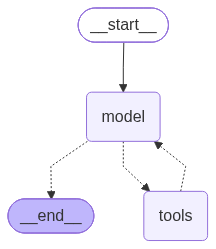

In [37]:
from langchain.tools import tool
from langchain.agents import create_agent
from langchain.messages import HumanMessage, ToolMessage


@tool
def search_documents(query: str) -> str:
    """AI 산업 동향 보고서에서 질문과 관련된 문서 청크를 검색합니다.

    Args:
        query: 검색할 질문 또는 키워드. 완성된 질문 형태일수록 좋습니다.

    Returns:
        검색된 문서 청크 (XML 형식)
    """
    return format_docs(ensemble_retriever.invoke(query))


AGENT_SYSTEM = '''당신은 QA(Question-Answering)를 수행하는 Assistant입니다.
Search_documents 툴로 보고서를 검색한 뒤, 검색 결과를 바탕으로 답변하세요.
한 번만 검색하지 말고, 추가 정보를 얻을 만한 쿼리를 선정하여 최대 세 번까지 검색하세요.
검색 결과 전체에 관련 정보가 없다면 "정보가 부족하여 답변할 수 없습니다."만 출력하세요.'''

agent = create_agent(llm, tools=[search_documents], system_prompt=AGENT_SYSTEM)
agent

In [38]:
# 툴 호출과 최종 답변 과정을 단계별로 확인합니다
sample_q = "트럼프 미국 대통령이 서명한 '제네시스 미션' 행정명령의 핵심 목표는 무엇인가요?"

for chunk in agent.stream({"messages": [HumanMessage(sample_q)]}, stream_mode="updates"):
    for step, data in chunk.items():
        message = data['messages'][-1]
        print(f"step: {step}")
        text = message.text
        if len(text) > 500:
            print(f"    content: {text[:500]} ... (중략)")
        else:
            print(f"    content: {text}")
        if step == 'model' and message.tool_calls:
            print("    tool_calls:", message.tool_calls)
        print('-------------')

step: model
    content: 
    tool_calls: [{'name': 'search_documents', 'args': {'query': "트럼프 '제네시스 미션' 행정명령 핵심 목표"}, 'id': 'call_fVi3zUduWtLdzamHDcnnC0dB', 'type': 'tool_call'}, {'name': 'search_documents', 'args': {'query': 'Genesis Mission executive order Trump 핵심 목표'}, 'id': 'call_z9aYlRrz9L8fnwK4fPCvszDW', 'type': 'tool_call'}, {'name': 'search_documents', 'args': {'query': '제네시스 미션 행정명령 목표 내용'}, 'id': 'call_ltqzDTJYuqtJz2FKHCcT7MeQ', 'type': 'tool_call'}]
-------------
step: tools
    content: <documents>
  <document index="1">
    <meta name="source">data/markdowns/SPRi AI Brief_1월호_산업동향_0102_F.md</meta>
    <content>이 내용은 2026년 1월호 SPRi AI Brief의 정책·법제 섹션 내 트럼프 미국 대통령 관련 '제네시스 미션' 행정명령에 관한 부분으로, 도널드 트럼프 대통령이 국가적 AI 과학 혁신 프로젝트인 제네시스 미션을 출범시켰음을 다룬다. 추진 체계는 미국 에너지부가 중심이 되어 과학안보 플랫폼을 구축·운영하며, 대통령 과학기술 보좌관과 국가과학기술위원회가 부처 간 조정을 총괄한다.

- n
- 도널드 트럼프 미국 대통령이 AI 기반 과학적 발견을 촉진해 미국의 기술적 우위와 글로벌 리더십을 강화하기 위한 국가적 프로젝트인 '제네시스 미션(Genesis Mission)' 출범 행정명령*에 서명 * Launching the Genesis Mission

In [39]:
def agent_rag_batch(questions):
    """Agent를 실행하고 (최종 답변, 툴 호출로 받은 검색 결과)를 반환합니다."""
    inputs = [{"messages": [HumanMessage(q)]} for q in questions]
    answers = [None] * len(questions)
    contexts = [None] * len(questions)

    for idx, output in tqdm(agent.batch_as_completed(inputs,
                                                    config={"recursion_limit": 10},
                                                    return_exceptions=True),
                            total=len(inputs), desc="Agent RAG"):
        if isinstance(output, Exception):
            print(f"#{idx} 실패: {type(output).__name__}")
            answers[idx] = "정보가 부족하여 답변할 수 없습니다."
            contexts[idx] = ["(검색 결과 없음)"]
            continue
        messages = output["messages"]
        answers[idx] = messages[-1].text
        # 툴 호출 횟수 = 검색 횟수
        contexts[idx] = [m.text for m in messages if isinstance(m, ToolMessage)] or ["(검색 결과 없음)"]

    return answers, contexts


await evaluate_rag('agent', agent_rag_batch)

Agent RAG: 100%|██████████| 20/20 [00:51<00:00,  2.55s/it]


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'bleu_score': 0.2322, 'context_recall': 0.7955, 'semantic_similarity': 0.8322, 'faithfulness': 0.7921, 'factual_correctness(mode=f1)': 0.7795}

## RAG 성능 평가 최종 비교 분석

### 1. RAGAS 평가 지표 요약

| RAG 방식       | Bleu Score | Context Recall | Semantic Similarity | Faithfulness | Factual Correctness (F1) |
| :------------- | :--------- | :------------- | :------------------ | :----------- | :----------------------- |
| **기본 RAG**   | 0.2633     | 0.7392         | 0.7966              | 0.7512       | 0.6920                   |
| **Multi-Query**| 0.2476     | **0.8400**     | 0.8376              | **0.8138**   | 0.7385                   |
| **하이브리드** | 0.2499     | 0.8108         | **0.8413**          | 0.7615       | 0.7325                   |
| **Rerank**     | 0.2615     | 0.7940         | 0.8079              | 0.7275       | 0.7105                   |
| **Contextual** | 0.2580     | **0.8548**     | **0.8476**          | 0.7523       | 0.7710                   |
| **Agentic**    | 0.2322     | 0.7955         | 0.8322              | 0.7921       | **0.7795**               |

### 2. 종합적인 분석 및 결론

이번 실험에서는 RAG의 다양한 고급 기법들을 평가하여 각 방법론의 강점과 약점을 비교했습니다. 주요 RAGAS 지표를 바탕으로 한 최종 분석 결과는 다음과 같습니다.

1.  **Contextual RAG의 약진**:
    *   `Context Recall` (0.8548)과 `Semantic Similarity` (0.8476)에서 **최고점**을 기록했습니다. 이는 문서 청크에 상위 문맥 정보를 풍부하게 추가하는 방식이, LLM이 질문에 필요한 관련 정보를 더 잘 회수하고, 의미적으로 유사한 답변을 생성하는 데 매우 효과적임을 강력하게 보여줍니다. `Factual Correctness`에서도 Agentic RAG 다음으로 높은 점수를 기록하여, 정보의 맥락을 강화하는 것이 답변의 정확도 향상에 크게 기여함을 입증했습니다.

2.  **Agentic RAG의 최고 사실 정확성**:
    *   `Factual Correctness` (0.7795)에서 **모든 방식 중 가장 높은 점수**를 기록했습니다. 또한 `Faithfulness` (0.7921)에서도 Multi-Query 다음으로 우수했습니다. 이는 LLM이 스스로 검색 쿼리를 생성하고, 툴을 활용하여 다단계로 정보를 탐색하며 답변을 구성하는 Agent 방식이 가장 정확하고 신뢰성 높은 답변을 도출하는 데 효과적임을 시사합니다. 비록 `Bleu Score`는 낮고 `Context Recall`이 Multi-Query나 Contextual보다 낮았지만, Agent의 유연한 탐색 능력이 답변의 핵심 품질을 높이는 데 결정적인 역할을 했습니다.

3.  **Multi-Query RAG의 전반적인 강세**:
    *   `Faithfulness` (0.8138)에서 **가장 높은 점수**를 기록했으며, `Context Recall` (0.8400)에서도 Contextual RAG 다음으로 우수했습니다. `Semantic Similarity`와 `Factual Correctness`에서도 상위권에 속했습니다. 다양한 쿼리 생성을 통한 광범위한 검색 전략은 환각 현상을 줄이고, LLM이 검색된 정보에 충실하게 답변하도록 유도하는 데 매우 효과적인 접근 방식임을 보여줍니다.

4.  **하이브리드(Ensemble) RAG의 안정적인 성능**:
    *   `Semantic Similarity` (0.8413)에서 Contextual RAG 다음으로 높은 점수를 보였고, 다른 지표들에서도 Multi-Query와 Contextual RAG에 준하는 안정적인 성능을 유지했습니다. 어휘적 검색(BM25)과 의미론적 검색(Embedding)의 조합이 균형 잡힌 검색 결과를 제공하여 안정적인 답변 품질을 유지하는 데 기여했습니다.

5.  **Rerank RAG의 제한된 개선**:
    *   `Bleu Score`에서는 기본 RAG와 유사하게 비교적 높은 점수를 보였으나, `Faithfulness` (0.7275)와 `Factual Correctness` (0.7105)에서는 Multi-Query, Contextual, Agentic, 하이브리드 방식에 비해 개선 효과가 제한적이었습니다. Reranker의 역할은 후보 컨텍스트를 선별하는 것이므로, LLM의 답변 생성 과정에 직접적으로 영향을 미치는 다른 Advanced 기법들만큼 전반적인 품질 향상을 이끌어내지 못했을 가능성이 있습니다.

6.  **기본 RAG의 한계**:
    *   모든 `Advanced RAG` 기법들이 `Context Recall`, `Semantic Similarity`, `Faithfulness`, `Factual Correctness`에서 **기본 RAG (Base RAG)**보다 우수한 성능을 보였습니다. 이는 단순한 검색만으로는 복잡한 질문에 대한 충분한 컨텍스트를 확보하거나 정확한 답변을 생성하는 데 한계가 있음을 명확하게 보여줍니다.

### 3. 최종 제언

이러한 결과를 바탕으로 볼 때, RAG 시스템의 성능을 극대화하기 위해서는:

*   **답변의 사실 정확성과 신뢰도**가 가장 중요하다면 **Agentic RAG**를 우선적으로 고려해 볼 수 있습니다. Agent의 동적인 탐색 능력이 가장 정확한 정보를 찾아내는 데 효과적이기 때문입니다.
*   **컨텍스트 회수율과 답변의 의미적 유사성**을 높이는 데 중점을 둔다면 **Contextual RAG**가 매우 강력한 선택이 될 수 있습니다. 문서 청크를 풍부하게 보강하는 전략은 LLM이 질문의 의도에 더 정확하게 부합하는 답변을 생성하는 데 큰 도움을 줍니다.
*   **환각을 최소화하고 검색된 컨텍스트에 충실한 답변**을 원한다면 **Multi-Query RAG**가 매우 효과적인 솔루션입니다.
*   안정적이고 균형 잡힌 성능을 원한다면 **하이브리드 RAG**가 좋은 선택이 될 수 있으며, 특정 상황에서 Lexical과 Semantic 검색의 장점을 결합하는 데 유용합니다.

실제 RAG 시스템 구현 시에는 애플리케이션의 특정 목표와 자원 제약(예: LLM 호출 비용, 지연 시간)을 고려하여 이 Advanced RAG 기법들을 **조합**하거나 **맞춤형으로 튜닝**하는 것이 최적의 결과를 얻는 데 중요할 것입니다.

## RAG 성능 평가 최종 비교 분석

### 1. RAGAS 평가 지표 요약

| RAG 방식       | Bleu Score | Context Recall | Semantic Similarity | Faithfulness | Factual Correctness (F1) |
| :------------- | :--------- | :------------- | :------------------ | :----------- | :----------------------- |
| **기본 RAG**   | 0.2633     | 0.7392         | 0.7966              | 0.7512       | 0.6920                   |
| **Multi-Query**| 0.2476     | **0.8400**     | 0.8376              | **0.8138**   | 0.7385                   |
| **하이브리드** | 0.2499     | 0.8108         | **0.8413**          | 0.7615       | 0.7325                   |
| **Rerank**     | 0.2615     | 0.7940         | 0.8079              | 0.7275       | 0.7105                   |
| **Contextual** | 0.2580     | **0.8548**     | **0.8476**          | 0.7523       | 0.7710                   |
| **Agentic**    | 0.2322     | 0.7955         | 0.8322              | 0.7921       | **0.7795**               |

### 2. 종합적인 분석 및 결론

이번 실험에서는 RAG의 다양한 고급 기법들을 평가하여 각 방법론의 강점과 약점을 비교했습니다. 주요 RAGAS 지표를 바탕으로 한 최종 분석 결과는 다음과 같습니다.

1.  **Contextual RAG의 약진**:
    *   `Context Recall` (0.8548)과 `Semantic Similarity` (0.8476)에서 **최고점**을 기록했습니다. 이는 문서 청크에 상위 문맥 정보를 풍부하게 추가하는 방식이, LLM이 질문에 필요한 관련 정보를 더 잘 회수하고, 의미적으로 유사한 답변을 생성하는 데 매우 효과적임을 강력하게 보여줍니다. `Factual Correctness`에서도 Agentic RAG 다음으로 높은 점수를 기록하여, 정보의 맥락을 강화하는 것이 답변의 정확도 향상에 크게 기여함을 입증했습니다.

2.  **Agentic RAG의 최고 사실 정확성**:
    *   `Factual Correctness` (0.7795)에서 **모든 방식 중 가장 높은 점수**를 기록했습니다. 또한 `Faithfulness` (0.7921)에서도 Multi-Query 다음으로 우수했습니다. 이는 LLM이 스스로 검색 쿼리를 생성하고, 툴을 활용하여 다단계로 정보를 탐색하며 답변을 구성하는 Agent 방식이 가장 정확하고 신뢰성 높은 답변을 도출하는 데 효과적임을 시사합니다. 비록 `Bleu Score`는 낮고 `Context Recall`이 Multi-Query나 Contextual보다 낮았지만, Agent의 유연한 탐색 능력이 답변의 핵심 품질을 높이는 데 결정적인 역할을 했습니다.

3.  **Multi-Query RAG의 전반적인 강세**:
    *   `Faithfulness` (0.8138)에서 **가장 높은 점수**를 기록했으며, `Context Recall` (0.8400)에서도 Contextual RAG 다음으로 우수했습니다. `Semantic Similarity`와 `Factual Correctness`에서도 상위권에 속했습니다. 다양한 쿼리 생성을 통한 광범위한 검색 전략은 환각 현상을 줄이고, LLM이 검색된 정보에 충실하게 답변하도록 유도하는 데 매우 효과적인 접근 방식임을 보여줍니다.

4.  **하이브리드(Ensemble) RAG의 안정적인 성능**:
    *   `Semantic Similarity` (0.8413)에서 Contextual RAG 다음으로 높은 점수를 보였고, 다른 지표들에서도 Multi-Query와 Contextual RAG에 준하는 안정적인 성능을 유지했습니다. 어휘적 검색(BM25)과 의미론적 검색(Embedding)의 조합이 균형 잡힌 검색 결과를 제공하여 안정적인 답변 품질을 유지하는 데 기여했습니다.

5.  **Rerank RAG의 제한된 개선**:
    *   `Bleu Score`에서는 기본 RAG와 유사하게 비교적 높은 점수를 보였으나, `Faithfulness` (0.7275)와 `Factual Correctness` (0.7105)에서는 Multi-Query, Contextual, Agentic, 하이브리드 방식에 비해 개선 효과가 제한적이었습니다. Reranker의 역할은 후보 컨텍스트를 선별하는 것이므로, LLM의 답변 생성 과정에 직접적으로 영향을 미치는 다른 Advanced 기법들만큼 전반적인 품질 향상을 이끌어내지 못했을 가능성이 있습니다.

6.  **기본 RAG의 한계**:
    *   모든 `Advanced RAG` 기법들이 `Context Recall`, `Semantic Similarity`, `Faithfulness`, `Factual Correctness`에서 **기본 RAG (Base RAG)**보다 우수한 성능을 보였습니다. 이는 단순한 검색만으로는 복잡한 질문에 대한 충분한 컨텍스트를 확보하거나 정확한 답변을 생성하는 데 한계가 있음을 명확하게 보여줍니다.

### 3. 최종 제언

이러한 결과를 바탕으로 볼 때, RAG 시스템의 성능을 극대화하기 위해서는:

*   **답변의 사실 정확성과 신뢰도**가 가장 중요하다면 **Agentic RAG**를 우선적으로 고려해 볼 수 있습니다. Agent의 동적인 탐색 능력이 가장 정확한 정보를 찾아내는 데 효과적이기 때문입니다.
*   **컨텍스트 회수율과 답변의 의미적 유사성**을 높이는 데 중점을 둔다면 **Contextual RAG**가 매우 강력한 선택이 될 수 있습니다. 문서 청크를 풍부하게 보강하는 전략은 LLM이 질문의 의도에 더 정확하게 부합하는 답변을 생성하는 데 큰 도움을 줍니다.
*   **환각을 최소화하고 검색된 컨텍스트에 충실한 답변**을 원한다면 **Multi-Query RAG**가 매우 효과적인 솔루션입니다.
*   안정적이고 균형 잡힌 성능을 원한다면 **하이브리드 RAG**가 좋은 선택이 될 수 있으며, 특정 상황에서 Lexical과 Semantic 검색의 장점을 결합하는 데 유용합니다.

실제 RAG 시스템 구현 시에는 애플리케이션의 특정 목표와 자원 제약(예: LLM 호출 비용, 지연 시간)을 고려하여 이 Advanced RAG 기법들을 **조합**하거나 **맞춤형으로 튜닝**하는 것이 최적의 결과를 얻는 데 중요할 것입니다.

## [부록] 실제 데이터에서 중요한 패턴들

- Time 메타데이터를 이용한 사전 필터링
- RAG 여부를 사전 판단하거나, 여러 개의 Vector DB 중 어느 DB를 검색할지 판단하는 단계
- 질문과 문서의 언어 일치 (한국어 --> 영어 변환 후 검색)

In [ ]:
display(detailed_result)

Here's what each column in the evaluation result means:

*   **bleu_score**: Measures the n-gram overlap between the generated answer (`response`) and the reference answer (`reference`). A higher score indicates a closer lexical match.
*   **context_recall**: Measures how well the retrieved documents (`retrieved_contexts`) cover all the necessary information present in the `reference` answer. A higher score means more relevant information was retrieved.
*   **semantic_similarity**: Evaluates the semantic similarity between the generated answer (`response`) and the reference answer (`reference`) using embeddings. A higher score indicates that the answers convey similar meanings.
*   **faithfulness**: Assesses whether the generated answer (`response`) is grounded in the retrieved documents (`retrieved_contexts`). A higher score indicates that the answer only uses information found in the retrieved context, avoiding hallucinations.
*   **factual_correctness(mode=f1)**: Measures the factual consistency between the generated answer (`response`) and the reference answer (`reference`). It's often an F1 score, balancing precision and recall of factual statements.

## Resources

### RAG의 다양한 시나리오

1) **전처리의 중요성**
   *   **질문**: 어제 회의에서 무슨 얘기했어? (+ 소속, 이름, 메시지 보낸 시간)
   *   **예시**: '2026년 8월 2일 AX전략 1팀 주간 Progress Meeting'
   *   **설명**: 질문에 포함된 시간, 소속 등 문맥 정보를 전처리하여 검색 쿼리에 활용하면 더 정확한 결과를 얻을 수 있습니다.

2) **의미 기반의 시맨틱 검색**
   *   **문서**: 사내 포크레인 운용 현황, 사내 덤프트럭 운용 현황, 사내 크레인 운용 현황
   *   **질문**: 현재 우리 중장비 몇 대 있어?
   *   **설명**: '포크레인', '덤프트럭', '크레인'이 모두 '중장비'라는 상위 개념으로 묶여 의미적으로 검색되어야 합니다.

3) **키워드 기반의 검색**
   *   **문서**: 엔비디아 H100 요금표, A100 요금표, A40 요금표, H200 요금표
   *   **질문**: A100 80시간 임대하는 비용이 얼마야?
   *   **설명**: 특정 모델명이나 시간과 같은 키워드를 정확하게 매칭하여 정보를 찾아야 하는 경우입니다.

4) **병렬 검색이 효과적인 질문**
   *   **질문**: 소설, IT, 역사 관련 이번 달 신작 알려줘.
   *   **예시**: (2026년 8월 소설 신간), (2026년 8월 IT 신간), ... 개별 검색
   *   **설명**: 여러 개의 독립적인 정보 요청이 포함된 질문은 각각의 서브 쿼리로 분할하여 병렬로 검색하는 것이 효율적입니다.

5) **여러 번의 연속 검색이 필요한 질문**
   *   **질문**: 삼성SDS의 클라우드 산업 경쟁사들이 27년에 진행하려고 하는 프로젝트에 대해 알려줘
   *   **단계**:
      1. '삼성SDS 클라우드 산업 경쟁사' 검색 --> B사, C사
      2. 'B사 2027 프로젝트' 검색 --> 성공
   *   **설명**: 하나의 질문을 해결하기 위해 여러 단계의 검색이 연속적으로 필요한 경우입니다. 이전 검색 결과가 다음 검색의 쿼리로 사용됩니다.

### RAG의 고정적 Workflow에서, Agentic RAG로의 변화 추세

기존의 RAG 파이프라인(`질문 --> 검색 --> 답변`)으로는 5번과 같이 여러 번의 연속 검색이 필요한 복잡한 질문을 효율적으로 해결하기 어렵습니다. 이러한 한계를 극복하기 위해, LLM이 스스로 검색을 계획하고 실행하며, 필요에 따라 쿼리를 수정하거나 검색을 반복하는 **Agentic RAG**로의 변화가 가속화되고 있습니다. Agentic RAG는 LLM에게 툴 사용 능력과 추론 능력을 부여하여, 더욱 복잡하고 동적인 정보 탐색 및 답변 생성을 가능하게 합니다.